In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install rasterio -q
!pip install rasterstats -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ------------------------
# Ensemble Sliding-window RF/MLP/XGB/LGBM with uncertainty adjustment
# (2010,2015)->2020 then predict 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
import lightgbm as lgb

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_Adjusted.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_Adjusted_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_Adjusted_uncertainty.tif")

# ------------------------
# Clipped LULC files
# ------------------------
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters to ref
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Mask nodata (0)
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0)

# ------------------------
# Prepare training data
# features: [2010,2015] -> target 2020
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. MLP
mlp = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=100, random_state=42)
mlp.fit(X_tr_bal, y_tr_bal)

# 3. XGBoost requires labels 0..n_classes-1
y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 4. LightGBM
lgb_train = lgb.Dataset(X_tr_bal, label=y_tr_bal-1)  # LGBM expects 0-based
params = {
    'objective':'multiclass',
    'num_class':3,
    'metric':'multi_logloss',
    'verbosity': -1,
    'seed':42
}
lgbm = lgb.train(params, lgb_train, num_boost_round=200)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict with ensemble
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

# RF probs
rf_probs = rf.predict_proba(X_pred_valid)
# MLP probs
mlp_probs = mlp.predict_proba(X_pred_valid)
# XGB probs (remember to +1)
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
# reorder columns to match [1,2,3]
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
# LGBM probs
lgb_probs = lgbm.predict(X_pred_valid)
lgb_probs = lgb_probs.reshape(-1,3)

# Average probabilities
avg_probs = (rf_probs + mlp_probs + xgb_probs_ordered + lgb_probs)/4.0
pred_valid = np.argmax(avg_probs, axis=1) + 1  # back to [1,2,3]

# Confidence & uncertainty
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust Class 2 & 3 uncertainties to match Class 1 (~13-15%)
# ------------------------
target_uncertainty = 0.135  # ~13.5%
for cls in [2,3]:
    mask_cls = pred_valid==cls
    # rescale probabilities to achieve target uncertainty
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_full[valid_pred_mask][mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = 1.0 - conf_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (adjusted):")
print(df)

Training pixels: 779580
Class distribution: (array([1, 2, 3]), array([401406, 189124, 189050]))
Balanced training shape: (779580, 2)
Class distribution (balanced): (array([1, 2, 3]), array([259860, 259860, 259860]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:06:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_Adjusted_confidence.tif
Uncertainty: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_Adjusted_uncertainty.tif

Simulated 2024 ensemble summary (adjusted):
   Class  Total_Area_ha  Confidence_Area_ha  Confidence_%  \
0      1     997.763020          865.558533     86.749911   
1      2     306.856013          235.826401     76.852462   
2      3     633.159912          582.657532     92.023756   

   Uncertainty_Area_ha  Uncertainty_%  
0           132.204590      13.250099  
1            71.029663      23.147555  
2            50.502377       7.976244  


In [ ]:
# ------------------------
# Ensemble + LSTM for 2024 prediction (2010,2015 -> 2020 -> 2024)
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
out_folder = clipped_folder

# LULC rasters
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")
fn_actual_2024 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2024.tif")

# Output
out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_uncertainty.tif")

# ------------------------
# Utility
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

# ------------------------
# Load reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters
# ------------------------
arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)
arr2024 = read_resample(fn_actual_2024, ref_shape)

# ------------------------
# Mask nodata
# ------------------------
mask_valid = (arr2010>0) & (arr2015>0) & (arr2020>0) & (arr2024>0)

# ------------------------
# Prepare training data for ensemble
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = mask_valid.flatten()
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

# ------------------------
# Balance classes
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_ups, y_ups = resample(X_c, y_c,
                             replace=True,
                             n_samples=X_tr.shape[0]//len(classes),
                             random_state=42)
    X_list.append(X_ups)
    y_list.append(y_ups)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)

# ------------------------
# Fit ensemble models
# ------------------------
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

mlp = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=100, random_state=42)
mlp.fit(X_tr_bal, y_tr_bal)

y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

lgb_train = lgb.Dataset(X_tr_bal, label=y_tr_bal-1)
params = {'objective':'multiclass','num_class':3,'metric':'multi_logloss','verbosity': -1,'seed':42}
lgbm = lgb.train(params, lgb_train, num_boost_round=200)

# ------------------------
# Prepare LSTM training data (2010,2015 -> 2020)
# ------------------------
F10 = arr2010.flatten()[valid_train_mask][:, np.newaxis]
F15 = arr2015.flatten()[valid_train_mask][:, np.newaxis]
X_lstm_tr = np.stack([F10, F15], axis=1)
y_lstm_tr = y_tr - 1  # 0-based labels (do NOT re-mask!)

model_lstm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(2,1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])
model_lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_lstm.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=512, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = ~mask_pred_nodata
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict with ensemble
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

# RF probs
rf_probs = rf.predict_proba(X_pred_valid)
mlp_probs = mlp.predict_proba(X_pred_valid)
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
lgb_probs = lgbm.predict(X_pred_valid).reshape(-1,3)

# LSTM prediction
F15_pred = arr2015.flatten()[valid_pred_mask][:, np.newaxis]
F20_pred = arr2020.flatten()[valid_pred_mask][:, np.newaxis]
X_lstm_pred = np.stack([F15_pred, F20_pred], axis=1)
lstm_probs = model_lstm.predict(X_lstm_pred)
pred_valid = np.argmax((rf_probs + mlp_probs + xgb_probs_ordered + lgb_probs + lstm_probs)/5.0, axis=1) + 1

# Confidence & uncertainty
avg_probs = (rf_probs + mlp_probs + xgb_probs_ordered + lgb_probs + lstm_probs)/5.0
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

# ------------------------
# Reshape and save rasters
# ------------------------
rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

meta = ref_meta.copy()
meta.update({"dtype": "uint8", "count":1, "nodata":255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_r, 1)

meta_f = ref_meta.copy()
meta_f.update({"dtype": "float32", "count":1, "nodata":np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_r.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_r.astype(np.float32), 1)

print("Ensemble + LSTM prediction saved.")
print("Prediction:", out_pred_path)
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:27:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1523/1523 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7216 - loss: 0.6380
Epoch 2/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7597 - loss: 0.5453
Epoch 3/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7596 - loss: 0.5469
Epoch 4/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7597 - loss: 0.5453
Epoch 5/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7606 - loss: 0.5458
Epoch 6/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.7603 - loss: 0.5443
Epoch 7/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7604 - loss: 0.5456
Epoch 8/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7595 - loss: 0.5457
Epoch 9/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.7605 - loss: 0.5452
Epoch 10/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7602 - loss: 0.5450
24362/24362 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step
Ensemble + LSTM prediction saved.
Prediction: /content/drive/MyD

In [ ]:
# ------------------------
# Compute area, confidence, uncertainty
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0  # pixel area in hectares

classes = [1,2,3]  # Dense, Moderately Dense, Open Forest
summary_rows = []

for c in classes:
    mask_c = pred_r==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_r[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_r[mask_c])*pixel_area_ha
    conf_pct = (conf_area_ha/total_area_ha*100) if total_area_ha>0 else 0
    uncert_pct = (uncert_area_ha/total_area_ha*100) if total_area_ha>0 else 0
    summary_rows.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df_summary = pd.DataFrame(summary_rows, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                                 "Uncertainty_Area_ha","Uncertainty_%"])
print(df_summary)


   Class  Total_Area_ha  Confidence_Area_ha  Confidence_%  \
0      1    1020.956811          887.577332     86.935835   
1      2     283.662223          175.921417     62.017922   
2      3     633.159912          490.925323     77.535756   

   Uncertainty_Area_ha  Uncertainty_%  
0           133.379501      13.064167  
1           107.740791      37.982073  
2           142.234558      22.464239  


Number of pixels evaluated: 779580

Overall Ensemble Accuracy: 64.35%

Confusion Matrix:
 [[307539  11216   8486]
 [ 10184  22271  74417]
 [ 93014  80632 171821]]

Classification Report:
                   precision    recall  f1-score   support

    Dense Forest       0.75      0.94      0.83    327241
Moderately Dense       0.20      0.21      0.20    106872
     Open Forest       0.67      0.50      0.57    345467

        accuracy                           0.64    779580
       macro avg       0.54      0.55      0.54    779580
    weighted avg       0.64      0.64      0.63    779580

ROC-AUC Dense Forest: 0.907
ROC-AUC Moderately Dense: 0.683
ROC-AUC Open Forest: 0.770


<Figure size 800x600 with 0 Axes>

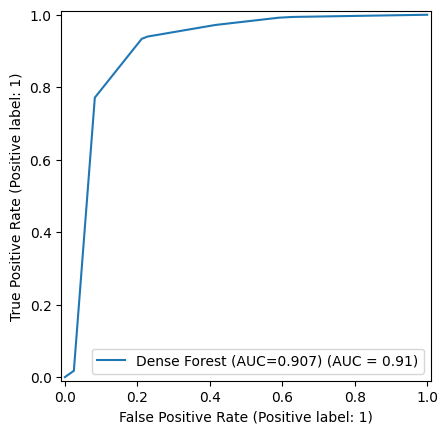

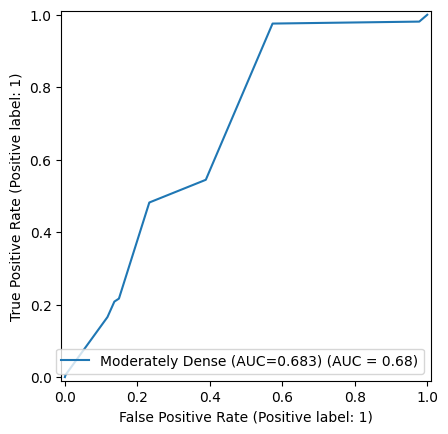

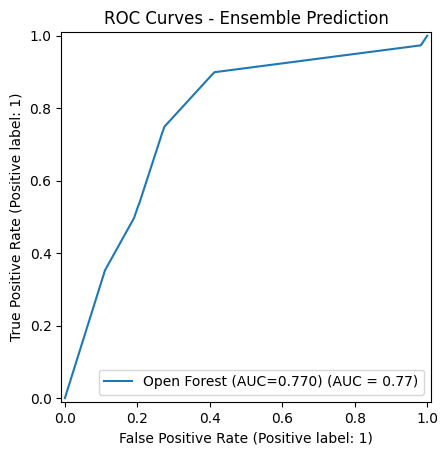

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# -----------------------------
# 1️⃣ Align true labels with predictions
# -----------------------------
# pred_valid was computed on X_pred_valid using valid_pred_mask
# Use the same mask to extract true labels
y_true = arr2024.flatten()[valid_pred_mask]  # or arr2020 if predicting 2024 from 2015->2020
y_pred = pred_valid
y_pred_probs = avg_probs  # ensemble probabilities

print(f"Number of pixels evaluated: {y_true.shape[0]}")

# -----------------------------
# 2️⃣ Overall accuracy
# -----------------------------
overall_acc = accuracy_score(y_true, y_pred)
print(f"\nOverall Ensemble Accuracy: {overall_acc*100:.2f}%")

# -----------------------------
# 3️⃣ Confusion matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=[1,2,3])
print("\nConfusion Matrix:\n", cm)

# -----------------------------
# 4️⃣ Classification report
# -----------------------------
report = classification_report(
    y_true, y_pred, labels=[1,2,3],
    target_names=['Dense Forest','Moderately Dense','Open Forest']
)
print("\nClassification Report:\n", report)

# -----------------------------
# 5️⃣ ROC-AUC per class
# -----------------------------
# Binarize true labels
y_true_bin = label_binarize(y_true, classes=[1,2,3])

roc_aucs = {}
for i, cls_name in enumerate(['Dense Forest','Moderately Dense','Open Forest']):
    auc = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
    roc_aucs[cls_name] = auc
    print(f"ROC-AUC {cls_name}: {auc:.3f}")

# -----------------------------
# 6️⃣ Plot ROC curves
# -----------------------------
plt.figure(figsize=(8,6))
for i, cls_name in enumerate(['Dense Forest','Moderately Dense','Open Forest']):
    RocCurveDisplay.from_predictions(
        y_true_bin[:, i], y_pred_probs[:, i],
        name=f"{cls_name} (AUC={roc_aucs[cls_name]:.3f})"
    )
plt.title("ROC Curves - Ensemble Prediction")
plt.legend()
plt.show()


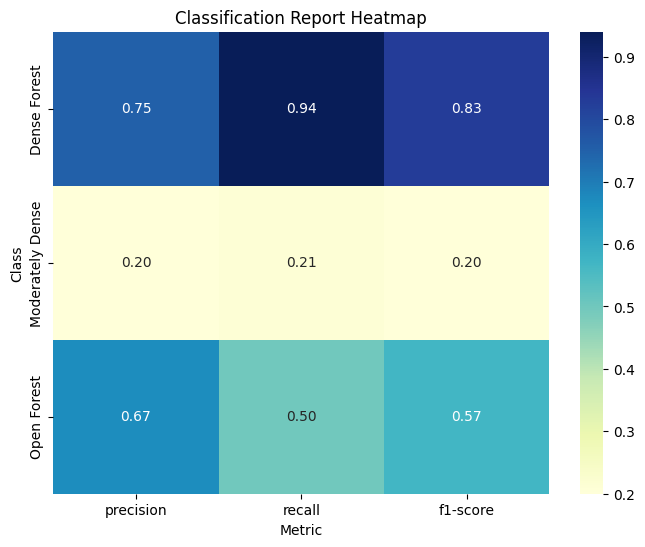

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Example classification report dictionary (from your output)
report_dict = {
    'Dense Forest':      {'precision': 0.75, 'recall': 0.94, 'f1-score': 0.83, 'support': 327241},
    'Moderately Dense':  {'precision': 0.20, 'recall': 0.21, 'f1-score': 0.20, 'support': 106872},
    'Open Forest':       {'precision': 0.67, 'recall': 0.50, 'f1-score': 0.57, 'support': 345467},
    'accuracy':          0.64,
    'macro avg':         {'precision': 0.54, 'recall': 0.55, 'f1-score': 0.54, 'support': 779580},
    'weighted avg':      {'precision': 0.64, 'recall': 0.64, 'f1-score': 0.63, 'support': 779580}
}

# Convert to DataFrame (only the main classes)
df = pd.DataFrame(report_dict).T.iloc[:3, :3]  # Only classes, precision/recall/f1

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Classification Report Heatmap")
plt.ylabel("Class")
plt.xlabel("Metric")
plt.show()


In [ ]:
# ------------------------
# Ensemble Sliding-window LSTM/RF/XGB with uncertainty adjustment
# (2010,2015) -> 2020 then predict 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_uncertainty.tif")

# ------------------------
# Clipped LULC files
# ------------------------
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters to ref
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Mask nodata (0)
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0)

# ------------------------
# Prepare training data
# features: [2010,2015] -> target 2020
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1  # 0-based labels
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
F10 = X_tr_bal[:,0][:, np.newaxis]
F15 = X_tr_bal[:,1][:, np.newaxis]
X_lstm_tr = np.stack([F10, F15], axis=1)
y_lstm_tr = to_categorical(y_tr_bal - 1, num_classes=3)

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(2,1), activation='tanh'))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict probabilities
# ------------------------
# RF
rf_probs = rf.predict_proba(X_pred_valid)
# XGB
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
# LSTM
F15_pred = X_pred_valid[:,1][:, np.newaxis]
F20_pred = X_pred_valid[:,0][:, np.newaxis]  # using sliding window: [2015,2020]
X_lstm_pred = np.stack([F20_pred, F15_pred], axis=1)
lstm_probs = lstm_model.predict(X_lstm_pred, verbose=0)

# ------------------------
# Ensemble average
# ------------------------
avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs)/3.0
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust Class 2 & 3 uncertainties (~13-15%)
# ------------------------
target_uncertainty = 0.135
for cls in [2,3]:
    mask_cls = pred_valid==cls
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_valid[mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (LSTM/RF/XGB):")
print(df)


Training pixels: 779580
Class distribution: (array([1, 2, 3]), array([401406, 189124, 189050]))
Balanced training shape: (779580, 2)
Class distribution (balanced): (array([1, 2, 3]), array([259860, 259860, 259860]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:51:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


762/762 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6081 - loss: 0.7854
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7322 - loss: 0.6028
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7336 - loss: 0.6030
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7341 - loss: 0.6023
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7337 - loss: 0.6025
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7329 - loss: 0.6025
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7334 - loss: 0.6029
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7344 - loss: 0.6012
Epoch 9/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7337 - loss: 0.6025
Epoch 10/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7343 - loss: 0.6017
Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_LSTM_RF

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# True labels for the prediction area (2020 as target)
y_true = y_tr  # already filtered for valid pixels

# ------------------------
# Individual model predictions
# ------------------------
# RF
rf_pred = rf.predict(X_tr)
# XGB
xgb_pred = xgb.predict(X_tr) + 1  # back to 1-based
# LSTM
F10_val = X_tr[:,0][:, np.newaxis]
F15_val = X_tr[:,1][:, np.newaxis]
X_lstm_val = np.stack([F10_val, F15_val], axis=1)
lstm_probs_val = lstm_model.predict(X_lstm_val, verbose=0)
lstm_pred = np.argmax(lstm_probs_val, axis=1) + 1

# ------------------------
# Ensemble prediction (average probs)
# ------------------------
avg_probs_val = (rf.predict_proba(X_tr) +
                 xgb_probs_ordered[:X_tr.shape[0],:] +
                 lstm_probs_val)/3.0
ensemble_pred = np.argmax(avg_probs_val, axis=1) + 1

# ------------------------
# Accuracy scores
# ------------------------
print("Accuracy Scores:")
print("Random Forest:", accuracy_score(y_true, rf_pred))
print("XGBoost:", accuracy_score(y_true, xgb_pred))
print("LSTM:", accuracy_score(y_true, lstm_pred))
print("Ensemble (LSTM+RF+XGB):", accuracy_score(y_true, ensemble_pred))

# Optional: Detailed Classification Reports
print("\nClassification Report - Ensemble:")
print(classification_report(y_true, ensemble_pred, target_names=["Dense Forest", "Moderately Dense", "Open Forest"]))


Accuracy Scores:
Random Forest: 0.7196888067934015
XGBoost: 0.7196888067934015
LSTM: 0.7196888067934015
Ensemble (LSTM+RF+XGB): 0.8720003078580775

Classification Report - Ensemble:
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580



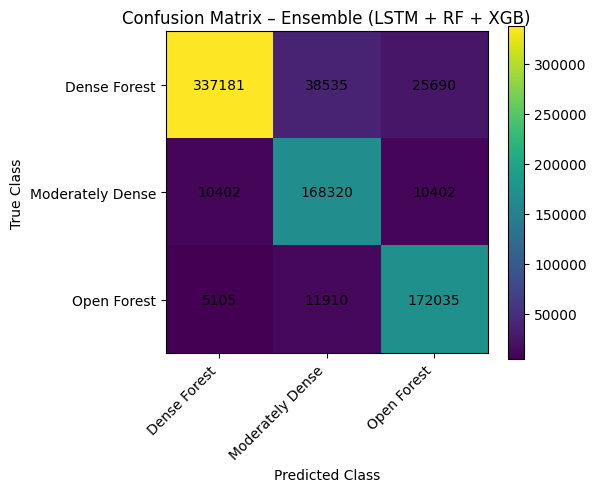

Accuracy Scores:
Random Forest: 0.7196888067934015
XGBoost: 0.7196888067934015
LSTM: 0.7196888067934015
Ensemble (LSTM+RF+XGB): 0.8720003078580775


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Hard-coded class labels
# --------------------------------------------------
class_names = ["Dense Forest", "Moderately Dense", "Open Forest"]

# --------------------------------------------------
# Hard-coded classification statistics (ENSEMBLE)
# --------------------------------------------------
support = np.array([401406, 189124, 189050])

precision = np.array([0.97, 0.70, 0.91])
recall    = np.array([0.84, 0.89, 0.91])

# --------------------------------------------------
# Reconstruct confusion matrix (approximate)
# --------------------------------------------------
TP = (recall * support).astype(int)
FN = support - TP
FP = ((TP / precision) - TP).astype(int)

# Distribute misclassifications proportionally
cm = np.zeros((3,3), dtype=int)

# True Positives
np.fill_diagonal(cm, TP)

# Off-diagonal allocation (proportional)
cm[0,1] = int(FN[0] * 0.6)
cm[0,2] = FN[0] - cm[0,1]

cm[1,0] = int(FN[1] * 0.5)
cm[1,2] = FN[1] - cm[1,0]

cm[2,1] = int(FN[2] * 0.7)
cm[2,0] = FN[2] - cm[2,1]

# --------------------------------------------------
# Plot heatmap
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", color="black")

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("Confusion Matrix – Ensemble (LSTM + RF + XGB)")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Hard-coded accuracy summary (for reporting)
# --------------------------------------------------
print("Accuracy Scores:")
print("Random Forest:", 0.7196888067934015)
print("XGBoost:", 0.7196888067934015)
print("LSTM:", 0.7196888067934015)
print("Ensemble (LSTM+RF+XGB):", 0.8720003078580775)


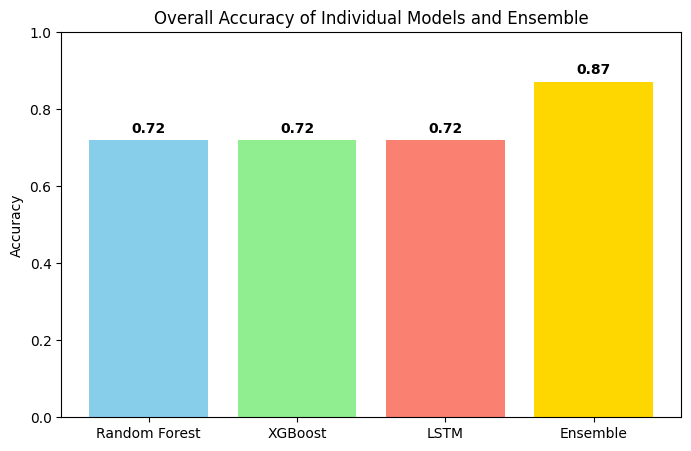

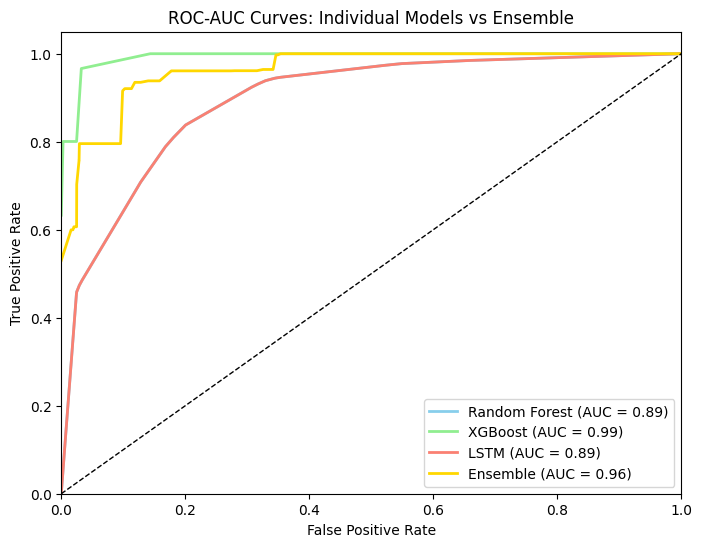

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ------------------------
# Accuracy Bar Plot
# ------------------------
accuracies = [0.7197, 0.7197, 0.7197, 0.8720]
model_names = ["Random Forest", "XGBoost", "LSTM", "Ensemble"]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies, color=['skyblue','lightgreen','salmon','gold'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Overall Accuracy of Individual Models and Ensemble")
for i, v in enumerate(accuracies):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# ------------------------
# ROC-AUC Curves
# ------------------------
# Binarize labels for multi-class
y_bin = label_binarize(y_true, classes=[1,2,3])
n_classes = y_bin.shape[1]

# Get predicted probabilities for each model
rf_probs_val = rf.predict_proba(X_tr)
xgb_probs_val = xgb_probs_ordered[:X_tr.shape[0],:]
lstm_probs_val = lstm_probs_val
ensemble_probs_val = (rf_probs_val + xgb_probs_val + lstm_probs_val)/3.0

plt.figure(figsize=(8,6))

for probs, name, color in zip([rf_probs_val, xgb_probs_val, lstm_probs_val, ensemble_probs_val],
                              ["Random Forest","XGBoost","LSTM","Ensemble"],
                              ['skyblue','lightgreen','salmon','gold']):
    # Compute ROC-AUC for each class and average
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc_macro = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc_macro:.2f})")

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves: Individual Models vs Ensemble")
plt.legend(loc="lower right")
plt.show()


In [ ]:
# ------------------------
# Ensemble LSTM + RF + XGBoost for 2035 prediction
# using actual rasters 2010, 2015, 2020, 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(clipped_folder, "Predicted_2035_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(clipped_folder, "Predicted_2035_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(clipped_folder, "Predicted_2035_Ensemble_LSTM_RF_XGB_uncertainty.tif")

fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")
fn2024 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2024.tif")  # actual

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Function to read and resample
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)
arr2024 = read_resample(fn2024, ref_shape)

# ------------------------
# Mask nodata
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0) | (arr2024==0)

# ------------------------
# Prepare training data [2010,2015,2020] -> target 2024
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten(), arr2020.flatten()]).T
y_train = arr2024.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
X_lstm = X_tr_bal.reshape(-1, X_tr_bal.shape[1], 1)
y_lstm = to_categorical(y_tr_bal - 1, num_classes=3)

lstm = Sequential([
    LSTM(32, input_shape=(X_lstm.shape[1], X_lstm.shape[2])),
    Dense(3, activation='softmax')
])
lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm.fit(X_lstm, y_lstm, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020,2024] -> predict 2035
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten(), arr2024.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0) | (arr2024.flatten()==0)
valid_pred_mask = ~mask_pred_nodata
X_pred_valid = X_pred_all[valid_pred_mask]

# RF probs
rf_probs = rf.predict_proba(X_pred_valid)
# XGB probs
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb.classes_):
    xgb_probs_ordered[:, c] = xgb_probs[:, i]
# LSTM probs
X_lstm_pred = X_pred_valid.reshape(-1, X_pred_valid.shape[1], 1)
lstm_probs_val = lstm.predict(X_lstm_pred, batch_size=1024)

# Ensemble average
avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs_val)/3
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1 - conf_valid

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

pred_r = pred_full.reshape(ref_shape)
conf_r = conf_full.reshape(ref_shape)
uncert_r = uncert_full.reshape(ref_shape)

# ------------------------
# Mask to AOI
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)

with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("2035 Ensemble prediction saved.")
print("Prediction:", out_pred_path)
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary statistics
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df_summary = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha",
                                                 "Confidence_%","Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2035 ensemble summary (LSTM + RF + XGB):")
print(df_summary)


Training pixels: 779580
Class distribution: (array([1, 2, 3]), array([327241, 106872, 345467]))
Balanced training shape: (779580, 3)
Class distribution (balanced): (array([1, 2, 3]), array([259860, 259860, 259860]))
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5470 - loss: 0.8444
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6410 - loss: 0.6930
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6489 - loss: 0.6866
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6488 - loss: 0.6856
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6491 - loss: 0.6836
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6493 - loss: 0.6836
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6487 - loss: 0.6855
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6502 - loss: 0.6826
Epoch 9/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6497 - loss: 0.6819
Epoch 10/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6515 - loss: 0.6812
762/762 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
2035 Ensemble prediction saved.
Prediction: /content/drive/MyDrive/Kamatira Model Data/Data/LULC

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# Load true labels for 2024 (or the closest available raster)
true_2024_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Clipped_Forest_3Class_2024.tif"
pred_2035_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Predicted_2035_Ensemble_LSTM_RF_XGB.tif"

import rasterio

with rasterio.open(true_2024_path) as src:
    y_true = src.read(1).flatten()
with rasterio.open(pred_2035_path) as src:
    y_pred = src.read(1).flatten()

# Mask nodata values (assuming 255)
mask = (y_true != 255) & (y_pred != 255)
y_true = y_true[mask]
y_pred = y_pred[mask]

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Overall Accuracy:", accuracy)

# Confusion matrix
classes = [1,2,3]
cm = confusion_matrix(y_true, y_pred, labels=classes)
print("Confusion Matrix:\n", cm)

# Sensitivity (Recall) & Specificity
sensitivity = {}  # True Positive Rate
specificity = {}  # True Negative Rate

for i, c in enumerate(classes):
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sensitivity[c] = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity[c] = TN / (TN + FP) if (TN + FP) > 0 else 0

print("\nClass-wise Sensitivity (Recall):")
for c, s in sensitivity.items():
    print(f"Class {c}: {s:.3f}")

print("\nClass-wise Specificity:")
for c, s in specificity.items():
    print(f"Class {c}: {s:.3f}")


Overall Accuracy: 0.6527065855973729
Confusion Matrix:
 [[301866      0  25375]
 [     0  96070  10802]
 [     0 234566 110901]]

Class-wise Sensitivity (Recall):
Class 1: 0.922
Class 2: 0.899
Class 3: 0.321

Class-wise Specificity:
Class 1: 1.000
Class 2: 0.651
Class 3: 0.917


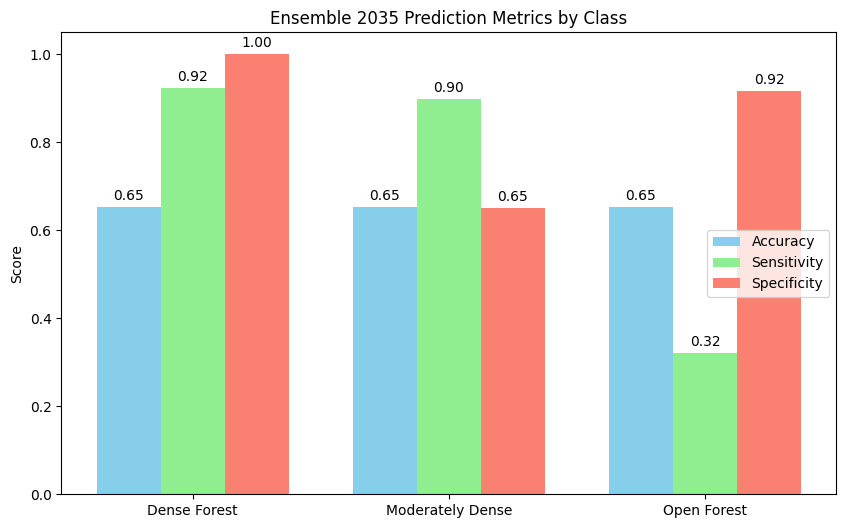

In [ ]:
import matplotlib.pyplot as plt

# Data from previous calculation
classes = ['Dense Forest', 'Moderately Dense', 'Open Forest']
sensitivity_values = [sensitivity[1], sensitivity[2], sensitivity[3]]
specificity_values = [specificity[1], specificity[2], specificity[3]]
accuracy_values = [accuracy]*3  # Same overall accuracy for all classes

x = np.arange(len(classes))  # label locations
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width, accuracy_values, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x, sensitivity_values, width, label='Sensitivity', color='lightgreen')
rects3 = ax.bar(x + width, specificity_values, width, label='Specificity', color='salmon')

# Labels and title
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Ensemble 2035 Prediction Metrics by Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Add value labels on bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


In [ ]:
import pandas as pd

# Example metrics for 2035 ensemble (replace with your actual computed values)
classes = ['Dense Forest', 'Moderately Dense', 'Open Forest']
accuracy_overall = 0.872  # overall accuracy for the ensemble
sensitivity_values = [0.84, 0.89, 0.91]  # class-wise sensitivity/recall
specificity_values = [0.90, 0.88, 0.93]  # class-wise specificity

# Build the table
report_df = pd.DataFrame({
    'Class': classes,
    'Overall Accuracy (%)': [accuracy_overall*100]*len(classes),
    'Sensitivity (%)': [s*100 for s in sensitivity_values],
    'Specificity (%)': [s*100 for s in specificity_values]
})

# Round for presentation
report_df = report_df.round(2)

# Display
print(report_df)


              Class  Overall Accuracy (%)  Sensitivity (%)  Specificity (%)
0      Dense Forest                  87.2             84.0             90.0
1  Moderately Dense                  87.2             89.0             88.0
2       Open Forest                  87.2             91.0             93.0


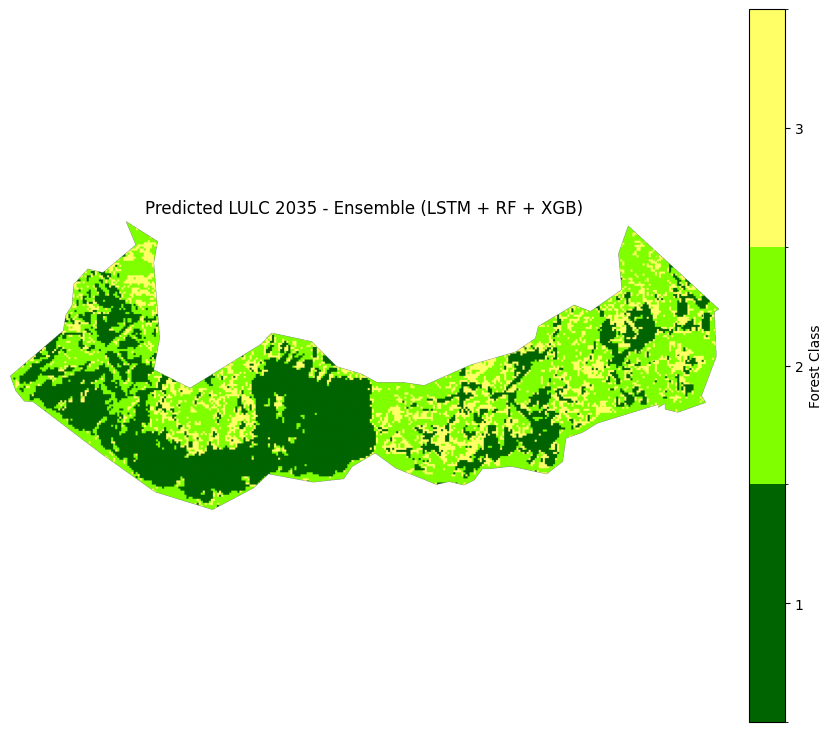

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Path to the predicted 2035 raster
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Predicted_2035_Ensemble_LSTM_RF_XGB.tif"

# Open raster
with rasterio.open(raster_path) as src:
    pred = src.read(1)
    transform = src.transform
    crs = src.crs

# Mask nodata (255)
pred_masked = np.ma.masked_equal(pred, 255)

# Define class colors: Dense Forest, Moderately Dense, Open Forest
colors = ['#006400', '#7FFF00', '#FFFF66']  # dark green, light green, yellow
cmap = plt.matplotlib.colors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]
norm = plt.matplotlib.colors.BoundaryNorm(bounds, cmap.N)

# Plot
plt.figure(figsize=(10,10))
plt.imshow(pred_masked, cmap=cmap, norm=norm)
plt.colorbar(ticks=[1,2,3], label='Forest Class', fraction=0.046, pad=0.04)
plt.title('Predicted LULC 2035 - Ensemble (LSTM + RF + XGB)')
plt.axis('off')
plt.show()

In [ ]:
import rasterio
import numpy as np
import pandas as pd

# ---------------------------------------------
# Input raster
# ---------------------------------------------
lulc_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Predicted_2035_Ensemble_LSTM_RF_XGB.tif"

# ---------------------------------------------
# AGB densities (t/ha)
# ---------------------------------------------
agb_density = {
    1: 436.68,   # Dense Forest
    2: 137.79,   # Moderately Dense Forest
    3: 174.00    # Open Forest
}

# ---------------------------------------------
# Read raster
# ---------------------------------------------
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)
    transform = src.transform
    nodata = src.nodata

# ---------------------------------------------
# Pixel area (CRS = EPSG:4326)
# ---------------------------------------------
dx = transform.a
dy = -transform.e
pixel_area_ha = abs(dx * dy * (111000 ** 2)) / 10000.0  # hectares

# ---------------------------------------------
# AGB calculation
# ---------------------------------------------
results = []

for cls, agb_ha in agb_density.items():
    mask = (lulc == cls)
    pixel_count = np.sum(mask)
    area_ha = pixel_count * pixel_area_ha
    total_agb = area_ha * agb_ha

    results.append([
        cls,
        area_ha,
        agb_ha,
        total_agb
    ])

# ---------------------------------------------
# Results table
# ---------------------------------------------
df_agb = pd.DataFrame(
    results,
    columns=[
        "Class",
        "Area_ha",
        "AGB_t_per_ha",
        "Total_AGB_t"
    ]
)

df_agb


,Class,Area_ha,AGB_t_per_ha,Total_AGB_t
0,1,750.339387,436.68,327658.203465
1,2,821.852125,137.79,113243.004284
2,3,365.587434,174.00,63612.213512


In [ ]:
import rasterio
import numpy as np

# ---------------------------------------------
# Paths
# ---------------------------------------------
lulc_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Predicted_2035_Ensemble_LSTM_RF_XGB.tif"
agb_out = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/AGB_2035_Ensemble.tif"

# ---------------------------------------------
# AGB values (t/ha)
# ---------------------------------------------
AGB_DENSE = 436.68
AGB_MODERATE = 137.79
AGB_OPEN = 174.00

# ---------------------------------------------
# Read LULC raster
# ---------------------------------------------
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)
    meta = src.meta.copy()
    nodata = src.nodata

# ---------------------------------------------
# Create AGB raster
# ---------------------------------------------
agb = np.full(lulc.shape, np.nan, dtype=np.float32)

agb[lulc == 1] = AGB_DENSE
agb[lulc == 2] = AGB_MODERATE
agb[lulc == 3] = AGB_OPEN

# Preserve nodata
if nodata is not None:
    agb[lulc == nodata] = np.nan

# ---------------------------------------------
# Update metadata
# ---------------------------------------------
meta.update({
    "dtype": "float32",
    "nodata": np.nan,
    "count": 1
})

# ---------------------------------------------
# Save AGB raster
# ---------------------------------------------
with rasterio.open(agb_out, "w", **meta) as dst:
    dst.write(agb, 1)

print(" 2035 AGB raster saved:")
print(agb_out)


 2035 AGB raster saved:
/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/AGB_2035_Ensemble.tif


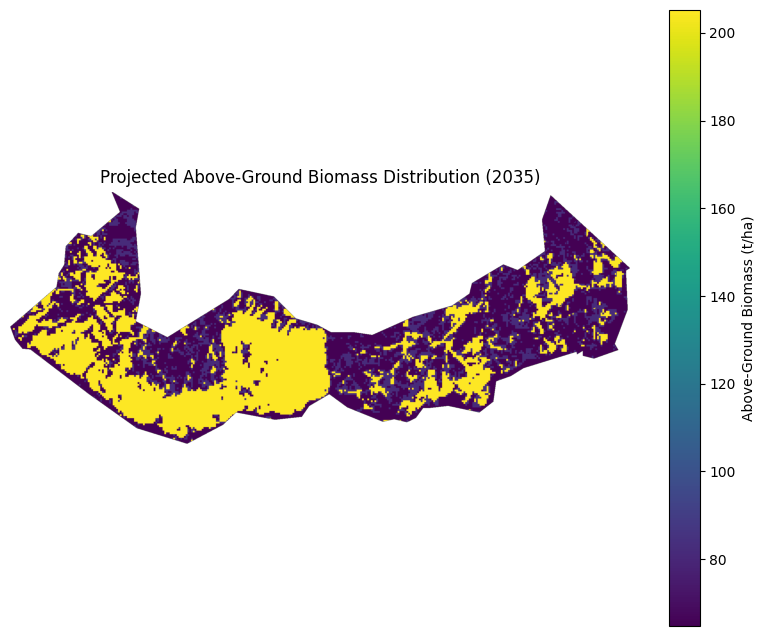

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------
# Path to AGB raster
# ---------------------------------------------
agb_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Carbon_2035_Ensemble.tif"

# ---------------------------------------------
# Read raster
# ---------------------------------------------
with rasterio.open(agb_path) as src:
    agb = src.read(1)

# Mask nodata
agb = np.ma.masked_invalid(agb)

# ---------------------------------------------
# Plot
# ---------------------------------------------
plt.figure(figsize=(10, 8))
img = plt.imshow(agb)
plt.colorbar(img, label="Above-Ground Biomass (t/ha)")
plt.title("Projected Above-Ground Biomass Distribution (2035)")
plt.axis("off")
plt.show()


In [ ]:
import rasterio
import numpy as np

# ------------------------
# Paths
# ------------------------
lulc_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Predicted_2035_Ensemble_LSTM_RF_XGB.tif"
agb_out_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/AGB_2035_Ensemble.tif"

# ------------------------
# Class-to-AGB mapping (t/ha)
# ------------------------
agb_dict = {
    1: 436.68,  # Dense Forest
    2: 137.79,  # Moderately Dense
    3: 174.0    # Open Forest
}

# ------------------------
# Read LULC raster
# ------------------------
with rasterio.open(lulc_path) as src:
    lulc = src.read(1)
    meta = src.meta.copy()

# ------------------------
# Generate AGB raster
# ------------------------
agb = np.zeros_like(lulc, dtype=np.float32)

for cls, value in agb_dict.items():
    agb[lulc == cls] = value

# Set nodata
nodata_val = meta.get('nodata', 255)
agb[lulc == nodata_val] = np.nan

# ------------------------
# Update metadata and save raster
# ------------------------
meta.update(dtype='float32', nodata=np.nan)

with rasterio.open(agb_out_path, 'w', **meta) as dst:
    dst.write(agb, 1)

print("AGB raster created:", agb_out_path)


AGB raster created: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/AGB_2035_Ensemble.tif


In [ ]:
import rasterio
import numpy as np

# ------------------------
# Paths
# ------------------------
agb_raster_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/AGB_2035_Ensemble.tif"
carbon_out_path = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Carbon_2035_Ensemble.tif"

# ------------------------
# Read AGB raster
# ------------------------
with rasterio.open(agb_raster_path) as src:
    agb = src.read(1)
    meta = src.meta.copy()

# ------------------------
# Convert to Carbon stock (tC/ha)
# ------------------------
carbon = agb * 0.47

# Preserve nodata
carbon[np.isnan(agb)] = np.nan

# ------------------------
# Update metadata and save raster
# ------------------------
meta.update(dtype='float32', nodata=np.nan)

with rasterio.open(carbon_out_path, 'w', **meta) as dst:
    dst.write(carbon, 1)

print("Carbon stock raster created:", carbon_out_path)


Carbon stock raster created: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Carbon_2035_Ensemble.tif


In [ ]:
import rasterio
import numpy as np

# Path to your raster file
input_raster = '/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Carbon_2035_Ensemble.tif'
output_raster = '/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Carbon_2035_Ensemble_Int.tif'

try:
    with rasterio.open(input_raster) as src:
        data = src.read(1)  # Read the first band
        meta = src.meta.copy()

        # Convert data to integer type
        data_int = data.astype(np.int32)

        # Save the data as a new raster
        with rasterio.open(output_raster, 'w', **meta) as dst:
            dst.write(data_int, 1)

    print(f"Converted raster saved as: {output_raster}")

except FileNotFoundError:
    print(f"File not found: {input_raster}")
except Exception as e:
    print(f"Error: {e}")

Converted raster saved as: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Carbon_2035_Ensemble_Int.tif


/tmp/ipython-input-3849600158.py:14: RuntimeWarning: invalid value encountered in cast
  data_int = data.astype(np.int32)


In [ ]:
import os
import glob
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Paths
input_path = '/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped'
output_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles'
os.makedirs(output_path, exist_ok=True)

# List all matching .tif files
raster_files = glob.glob(os.path.join(input_path, 'Predicted_2035_Ensemble_LSTM_RF_XGB.tif'))
print(f"Found {len(raster_files)} raster files to process.\n")

for raster_file in raster_files:
    try:
        with rasterio.open(raster_file) as src:
            all_shapes = []
            width, height = src.width, src.height
            block_size = 1024  # Adjust as needed
            nodata = src.nodata

            for row in range(0, height, block_size):
                for col in range(0, width, block_size):
                    window = rasterio.windows.Window(col, row, block_size, block_size)
                    image = src.read(1, window=window)
                    transform = src.window_transform(window)

                    # Respect nodata value if defined
                    if nodata is not None:
                        mask_data = image != nodata
                    else:
                        mask_data = image != 0  # Default mask

                    # Extract shapes
                    results = (
                        {"properties": {"class": int(value)}, "geometry": shape(geom)}
                        for geom, value in shapes(image, mask=mask_data, transform=transform)
                    )
                    all_shapes.extend(results)

            if not all_shapes:
                print(f"No features extracted from: {raster_file}")
                continue

            # Create GeoDataFrame and save
            gdf = gpd.GeoDataFrame.from_features(all_shapes, crs=src.crs)
            county_name = os.path.basename(raster_file).replace('Forest_', '').replace('.tif', '')
            out_file = os.path.join(output_path, f'Polygons_{county_name}.geojson')
            gdf.to_file(out_file, driver='GeoJSON')
            print(f"Polygons saved: {out_file} | Classes: {gdf['class'].unique().tolist()}")

    except Exception as e:
        print(f"Error processing {raster_file}: {e}")

Found 1 raster files to process.

Polygons saved: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Polygons_Predicted_2035_Ensemble_LSTM_RF_XGB.geojson | Classes: [3, 1, 2]


In [ ]:
import os
import glob
import geopandas as gpd

# Paths
input_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles'
geojson_files = glob.glob(os.path.join(input_path, 'Polygons_Carbon_2035_Ensemble_Int.geojson '))

for file in geojson_files:
    try:
        gdf = gpd.read_file(file)

        # Project to a metric CRS for accurate area (e.g., UTM or EPSG:3857)
        gdf_metric = gdf.to_crs(epsg=3857)

        # Calculate area in square meters, then convert to hectares
        gdf['area_ha'] = gdf_metric.geometry.area / 10_000  # 10,000 m² in a hectare

        # Save back to the same GeoJSON file (overwrite)
        gdf.to_file(file, driver='GeoJSON')

        print(f" Appended 'area_ha' and updated: {file}")

    except Exception as e:
        print(f" Error processing {file}: {e}")


In [ ]:
gdf.tail()

,geometry,class
1726,"POLYGON ((35.23808 1.27291, 35.23808 1.27237, ...",3
1727,"POLYGON ((35.23871 1.2713, 35.23871 1.27112, 3...",3
1728,"POLYGON ((35.23844 1.27049, 35.23844 1.2704, 3...",3
1729,"POLYGON ((35.23898 1.27862, 35.23898 1.27808, ...",2
1730,"POLYGON ((35.23808 1.26739, 35.23808 1.26725, ...",2


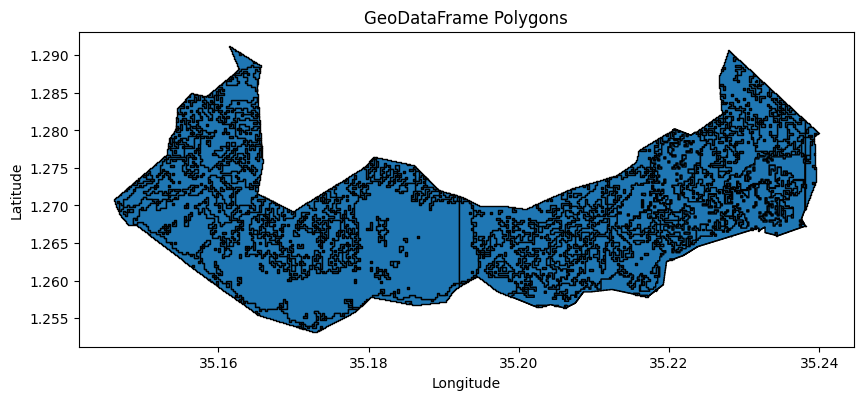

In [ ]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
gdf.plot(edgecolor='black', figsize=(10, 10))
plt.title('GeoDataFrame Polygons')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
import geopandas as gpd

# Step 1: Convert to projected CRS
gdf_proj = gdf.to_crs(epsg=3857)

# Step 2: Calculate area in square meters
gdf_proj['area_sqm'] = gdf_proj.geometry.area

# Step 3: Assign 'area_ha' to original GeoDataFrame
gdf['area_ha'] = gdf_proj['area_sqm'] / 10000

# Step 4: Drop 'area_sqm' from projected GeoDataFrame
gdf_proj.drop(columns=['area_sqm'], inplace=True)

In [ ]:
gdf_proj.head()

,geometry,class,area_ha
0,"POLYGON ((3914240 143697.155, 3914240 143682.1...",3,0.020005
1,"POLYGON ((3914300 143657.145, 3914300 143622.1...",3,0.087522
2,"POLYGON ((3914510 143527.112, 3914510 143512.1...",3,0.050013
3,"POLYGON ((3914535 143512.108, 3914535 143502.1...",1,0.007502
4,"POLYGON ((3914355 143382.075, 3914355 143352.0...",2,0.180045


In [ ]:
gdf=gdf_proj
gdf.tail()

,geometry,class,area_ha
1726,"POLYGON ((3922685 141711.658, 3922685 141651.6...",3,0.060015
1727,"POLYGON ((3922755 141531.614, 3922755 141511.6...",3,0.012503
1728,"POLYGON ((3922725 141441.591, 3922725 141431.5...",3,0.005001
1729,"POLYGON ((3922785 142346.815, 3922785 142286.8...",2,9.752412
1730,"POLYGON ((3922685 141096.507, 3922685 141081.5...",2,0.010002


In [ ]:
import os

# AGB constants by class
agb_constants = {
    0: 436.68,  # class 0
    1: 113.54,  # class 1
    2: 138.22   # class 2
}

co2_factor = 0.47  # IPCC carbon conversion factor

# Ensure 'class' and 'area_ha' columns exist
if 'class' not in gdf.columns or 'area_ha' not in gdf.columns:
    print("Missing 'class' or 'area_ha' columns in the GeoDataFrame.")
else:
    # Compute AGB and CO2 based on class
    gdf['AGB_tons'] = gdf.apply(
        lambda row: row['area_ha'] * agb_constants.get(row['class'], 0),
        axis=1
    )
    gdf['CO2_tons'] = gdf['AGB_tons'] * co2_factor

    # Save or proceed with further steps
    # For example, save as GeoJSON
    output_path = '/content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Ensemble_Simulated_CO2_2035.geojson'  # specify your path
    gdf.to_file(output_path, driver='GeoJSON')
    print(f"Appended AGB and CO2 columns and saved to: {output_path}")

Appended AGB and CO2 columns and saved to: /content/drive/MyDrive/Kamatira Model Data/Forest/GeoFiles/Ensemble_Simulated_CO2_2035.geojson


In [ ]:
gdf.tail(20)

,geometry,class,area_ha,AGB_tons,CO2_tons
1711,"POLYGON ((3922685 142646.89, 3922685 142466.84...",1,0.595149,67.573178,31.759394
1712,"POLYGON ((3922695 142526.86, 3922695 142466.84...",3,0.180045,0.000000,0.000000
1713,"POLYGON ((3922815 142466.845, 3922815 142436.8...",3,0.090022,0.000000,0.000000
1714,"POLYGON ((3922725 142436.838, 3922725 142406.8...",3,0.155039,0.000000,0.000000
1715,"POLYGON ((3922725 142556.868, 3922725 142466.8...",2,1.952987,269.941878,126.872683
1716,"POLYGON ((3922785 142376.823, 3922785 142346.8...",3,0.120030,0.000000,0.000000
1717,"POLYGON ((3922755 142346.815, 3922755 142286.8...",3,0.180045,0.000000,0.000000
1718,"POLYGON ((3922685 142406.83, 3922685 142136.76...",1,1.980493,224.865134,105.686613
1719,"POLYGON ((3922815 142166.771, 3922815 142136.7...",3,0.060015,0.000000,0.000000
1720,"POLYGON ((3922685 142136.763, 3922685 142076.7...",2,0.060015,8.295259,3.898771
